
# 🧬 Biomedical RAG Chatbot

## Project Overview

This project implements a Retrieval-Augmented Generation (RAG)
system for biomedical question answering.

The system:
1. Retrieves relevant biomedical literature.
2. Ranks evidence using semantic similarity.
3. Generates a concise answer from retrieved evidence.
4. Displays the top 3 evidence chunks.
5. Reports evidence reliability.

## Technologies

- Python
- FAISS
- Sentence Transformers
- Hugging Face Transformers
- Biomedical literature
- Gradio




# Biomedical Question Answering with Retrieval-Augmented Generation (RAG)

**A comparison of baseline LLM answering vs. retrieval-grounded answering on biomedical QA benchmarks**

This notebook is self-contained and can be run top to bottom in Google Colab.

## 2. Research Problem

General-purpose LLMs are often used to answer scientific and biomedical questions, but they generate
answers purely from parameters learned at training time. They have no built-in mechanism to check their
answer against a real source, and no access to literature published after their training cutoff.

This project asks a narrow, testable question: **for biomedical question answering, does retrieving
relevant literature before generation (RAG) produce better, more grounded answers than a baseline LLM
that only uses its parametric knowledge?**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Research Gap

General-purpose LLMs can hallucinate scientific facts and may not have access to the biomedical
literature relevant to a specific question. There is limited hands-on comparison, at small/reproducible
scale, of exactly *how much* retrieval helps (or doesn't) on standard biomedical QA benchmarks, using
metrics that are actually computed rather than assumed.

## 4. Research Objectives

1. Build a simple, working biomedical RAG pipeline (embed → FAISS → retrieve → generate).
2. Evaluate it on two different biomedical QA datasets (BioASQ, PubMedQA).
3. Compare a baseline LLM against the same LLM augmented with retrieval, using real computed metrics.
4. Compare a smaller vs. larger generation model on the same test set.
5. Report honestly, including cases where RAG does **not** improve the metric.

## 5. Overall Pipeline

```
Dataset (BioASQ / PubMedQA)
        |
Data preprocessing (clean text, build passage corpus)
        |
Train/Test split (held-out demo set vs. evaluation test set)
        |
   ------------------------------
   |                            |
Baseline path                RAG path
   |                            |
LLM (FLAN-T5)          Query embedding -> FAISS -> Top-K evidence -> LLM
   |                            |
Predicted answer          Evidence-grounded answer
   ------------------------------
        |
Compare with correct answer -> Accuracy / F1 / EM
        |
Compare models, compare datasets, compare baseline vs RAG
        |
Conclusion
```

## 6. Dataset Overview

Two biomedical QA datasets are used, chosen because they have **real gold answers** and are small enough
to run in Colab without downloading unnecessary data:

- **BioASQ-mini** (`rag-datasets/rag-mini-bioasq`) — open, free-text biomedical QA pairs, with a
  companion corpus of 40,221 real PubMed passages linked to each question via gold `relevant_passage_ids`.
- **PubMedQA** (`qiaojin/PubMedQA`, `pqa_labeled` config) — 1,000 questions, each with its own supporting
  context passages and a `yes` / `no` / `maybe` gold label (the dataset's standard task).

Both are loaded directly from the Hugging Face Hub; only small, fixed-size samples are used (see
Section 11), not the full datasets.

## 7. Dataset Comparison

| Property | BioASQ-mini | PubMedQA (pqa_labeled) |
|---|---|---|
| Purpose | Open biomedical fact QA | Yes/No/Maybe research-question QA |
| Question format | Natural-language question | Natural-language question (often a yes/no research question) |
| Answer format | Free-text sentence(s) | Categorical label (`yes`/`no`/`maybe`) + long-form explanation |
| Context/passages available | Yes, via a separate 40,221-passage corpus + gold passage IDs per question | Yes, directly attached to each question (1-4 passages) |
| Domain | General biomedical literature (PubMed) | General biomedical literature (PubMed) |
| Train/test availability | Single `test` split (4,719 rows); we sample from it | Single `train` split (1,000 rows, expert-labeled); we sample from it |
| Suitability for this project | Good for open-answer generation + retrieval-hit evaluation | Good for a clean, single-metric (Accuracy) classification-style QA task |

**Why both:** BioASQ tests free-text generation (harder to score, more realistic RAG use case).
PubMedQA tests a constrained classification task (easy to score objectively). Using both lets us see
whether RAG's effect depends on task type — this is exactly the comparison requested in Section 21.

## 8. Environment Setup

Mount Google Drive (if running in Colab) and install the packages this notebook needs. Everything this
notebook produces is saved under `/content/drive/MyDrive/INLP_Project/` — never only in `/content`.

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Colab — assuming the project path is already accessible.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q sentence-transformers faiss-cpu biopython datasets

In [ ]:
import os
import re
import json
import string
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import faiss
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from Bio import Entrez

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

PROJECT_DIR = "/content/drive/MyDrive/INLP_Project"
DATA_DIR = f"{PROJECT_DIR}/data"
OUTPUT_DIR = f"{PROJECT_DIR}/outputs"
VECTOR_DIR = f"{PROJECT_DIR}/vector_store"
for d in (DATA_DIR, OUTPUT_DIR, VECTOR_DIR):
    os.makedirs(d, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


## 9. Data Loading

`load_dataset(name)` loads one of the two QA datasets plus the BioASQ passage corpus, straight from the
Hugging Face Hub. A small, targeted set of **live** PubMed abstracts is also pulled via NCBI Entrez —
this keeps the retrieval corpus connected to current literature (directly relevant to the "LLMs lack
access to the latest literature" part of the research gap), and specifically covers the topic used in the
final demonstration question (Alzheimer's drug targets).

In [ ]:
def load_dataset_bundle():
    """Load BioASQ QA pairs, the BioASQ passage corpus, and PubMedQA."""
    bioasq_qa = load_dataset(
        "rag-datasets/rag-mini-bioasq", "question-answer-passages", split="test"
    ).shuffle(seed=42)

    bioasq_corpus = load_dataset(
        "rag-datasets/rag-mini-bioasq", "text-corpus", split="passages"
    )

    pubmedqa = load_dataset(
        "qiaojin/PubMedQA", "pqa_labeled", split="train"
    ).shuffle(seed=42)

    return bioasq_qa, bioasq_corpus, pubmedqa


bioasq_qa, bioasq_corpus_full, pubmedqa = load_dataset_bundle()
print("BioASQ QA pairs:", len(bioasq_qa))
print("BioASQ passage corpus:", len(bioasq_corpus_full))
print("PubMedQA:", len(pubmedqa))

README.md:   0%|          | 0.00/813 [00:00<?, ?B/s]

data/test.parquet/part.0.parquet: reconstructing file:   0%|          |  0.00B / 1.29MB            

data/test.parquet/part.0.parquet: downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4719 [00:00<?, ? examples/s]

data/passages.parquet/part.0.parquet: reconstructing file:   0%|          |  0.00B / 24.5MB            

...

README.md:   0%|          | 0.00/5.19k [00:00<?, ?B/s]

pqa_labeled/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.08MB            

pqa_labeled/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

BioASQ QA pairs: 4719
BioASQ passage corpus: 40221
PubMedQA: 1000


In [ ]:
def fetch_live_pubmed(queries, email, cache_path):
    """Fetch a small set of live PubMed abstracts via Entrez. Falls back to a
    cached copy (data/pubmed_live_chunks.json) if the network call fails, so
    the notebook still runs if NCBI is briefly unavailable."""
    Entrez.email = email
    docs = []
    try:
        for query, retmax in queries:
            handle = Entrez.esearch(db="pubmed", term=query, retmax=retmax)
            pm_ids = Entrez.read(handle)["IdList"]
            handle.close()
            if not pm_ids:
                continue
            fetch = Entrez.efetch(db="pubmed", id=",".join(pm_ids), rettype="abstract", retmode="text")
            raw_text = fetch.read()
            fetch.close()
            for raw_doc in raw_text.split("\n\n\n"):
                if len(raw_doc.strip()) > 200:
                    docs.append({"raw": raw_doc.strip(), "query": query})
        with open(cache_path, "w") as f:
            json.dump(docs, f)
    except Exception as e:
        print(f"Live PubMed fetch failed ({e}); using cached copy instead.")
        with open(cache_path) as f:
            docs = json.load(f)
    return docs


ENTREZ_QUERIES = [
    ("Alzheimer's disease AND molecular target", 60),
    ("drug repurposing AND target identification", 40),
]
pubmed_live_raw = fetch_live_pubmed(
    ENTREZ_QUERIES,
    email="dudukuruyuvaraj55@gmail.com",
    cache_path=f"{DATA_DIR}/pubmed_live_chunks.json",
)
print(f"Fetched/loaded {len(pubmed_live_raw)} live PubMed abstract blocks.")

Fetched/loaded 100 live PubMed abstract blocks.


## 10. Data Preprocessing

`preprocess_data()` cleans raw text into retrieval-ready passages:

- **BioASQ / PubMedQA passages** are already short, single-purpose units of text (one passage = one
  retrieval chunk), so no further splitting is needed — this is our chunking strategy: use the dataset's
  natural passage boundaries instead of an arbitrary sliding window.
- **Live PubMed abstracts** are noisier (citation lines, author lists, affiliations), so we strip that
  boilerplate and keep only the title + abstract body.

In [ ]:
def clean_live_abstract(raw):
    """Keep the title (2nd paragraph block) + the longest remaining paragraph
    block (reliably the abstract body); drops citation/author/affiliation text."""
    blocks = [b.strip() for b in raw.split("\n\n") if b.strip()]
    if not blocks:
        return ""
    title = blocks[1] if len(blocks) > 1 else ""
    candidates = [
        b for b in blocks[2:]
        if "Author information" not in b and not b.startswith("(") and len(b) > 200
    ]
    abstract = max(candidates, key=len) if candidates else (blocks[-1] if blocks else "")
    text = f"{title}. {abstract}" if title and title not in abstract else abstract
    return re.sub(r"\s+", " ", text).strip()


def preprocess_data(pubmed_live_raw):
    """Clean the live PubMed abstracts into short deduplicated chunks."""
    seen, chunks = set(), []
    for doc in pubmed_live_raw:
        cleaned = clean_live_abstract(doc["raw"])
        if len(cleaned) < 150 or cleaned in seen:
            continue
        seen.add(cleaned)
        if len(cleaned) > 1500:
            mid = len(cleaned) // 2
            split_at = cleaned.find(". ", mid)
            split_at = split_at + 1 if split_at != -1 else mid
            parts = [cleaned[:split_at].strip(), cleaned[split_at:].strip()]
        else:
            parts = [cleaned]
        for p in parts:
            if len(p) >= 100:
                chunks.append({"text": p[:1200], "source": "PubMed-live", "orig_id": None})
    return chunks


pubmed_live_chunks = preprocess_data(pubmed_live_raw)
print("Cleaned live PubMed chunks:", len(pubmed_live_chunks))
print("\nExample cleaned chunk:\n", pubmed_live_chunks[0]["text"][:300])

Cleaned live PubMed chunks: 183

Example cleaned chunk:
 Chemical probes for Alzheimer's disease targets.. Alzheimer's disease (AD) is a complex neurodegenerative disorder involving amyloid-β deposition, tau aggregation, neuroinflammation, synaptic dysfunction, and microvascular and epigenetic changes. Although recent therapeutic developments have energis


## 11. Train / Test Split

This project uses **pretrained models via inference and retrieval — no fine-tuning** — so there is no
conventional training split. Instead, each dataset is split into:

- a **test set** (BioASQ n=15, PubMedQA n=20) used for every quantitative metric in this notebook, and
- a small **demo set** (3 questions per dataset, disjoint from the test set) reserved only for the
  qualitative walkthrough in Section 24, so the test-set numbers are never influenced by having looked at
  those specific examples first.

Sample sizes are intentionally small so the whole notebook, including live model inference, runs in a
few minutes on a Colab CPU runtime. **Results below are therefore a small pilot, not a
statistically powerful evaluation** — see Section 26 (Limitations).

In [ ]:
N_BIOASQ_TEST, N_BIOASQ_DEMO = 15, 3
N_PUBMEDQA_TEST, N_PUBMEDQA_DEMO = 20, 3
N_PUBMEDQA_DISTRACTOR_ROWS = 250   # extra rows used only to add distractor passages to the corpus
K_RETRIEVE = 5

# ---- BioASQ QA split ----
bioasq_rows = []
for row in bioasq_qa.select(range(N_BIOASQ_TEST + N_BIOASQ_DEMO)):
    ids = row["relevant_passage_ids"]
    ids = json.loads(ids) if isinstance(ids, str) else ids
    bioasq_rows.append({
        "question": row["question"], "answer": row["answer"],
        "relevant_passage_ids": [int(i) for i in ids],
    })
bioasq_test = bioasq_rows[:N_BIOASQ_TEST]
bioasq_demo = bioasq_rows[N_BIOASQ_TEST:]

# ---- PubMedQA split ----
pubmedqa_rows = []
n_pull = N_PUBMEDQA_TEST + N_PUBMEDQA_DEMO + N_PUBMEDQA_DISTRACTOR_ROWS
for row in pubmedqa.select(range(n_pull)):
    ctx = row["context"]["contexts"] if row["context"] else []
    pubmedqa_rows.append({
        "pubid": row["pubid"], "question": row["question"], "contexts": ctx,
        "long_answer": row["long_answer"], "final_decision": row["final_decision"],
    })
pubmedqa_test = pubmedqa_rows[:N_PUBMEDQA_TEST]
pubmedqa_demo = pubmedqa_rows[N_PUBMEDQA_TEST:N_PUBMEDQA_TEST + N_PUBMEDQA_DEMO]
pubmedqa_distractor_rows = pubmedqa_rows[N_PUBMEDQA_TEST + N_PUBMEDQA_DEMO:]

print(f"BioASQ:   test={len(bioasq_test)}  demo={len(bioasq_demo)}")
print(f"PubMedQA: test={len(pubmedqa_test)}  demo={len(pubmedqa_demo)}  distractor_rows={len(pubmedqa_distractor_rows)}")

BioASQ:   test=15  demo=3
PubMedQA: test=20  demo=3  distractor_rows=250


## 12. Baseline Model

The baseline generation model is **FLAN-T5-base** (`google/flan-t5-base`, 250M parameters) — an
instruction-tuned seq2seq model that is small enough to run on a Colab CPU runtime in reasonable time,
while still following natural-language instructions well enough to answer or abstain sensibly.

**FLAN-T5-small** (`google/flan-t5-small`, 80M parameters) is also loaded, used later only in the
model-comparison experiment (Section 20) as a smaller/faster point of comparison. No larger model is
introduced, in line with keeping this notebook practical to run end-to-end in Colab.

In [ ]:
GEN_MODELS = {}
for key, name in [("flan-t5-small", "google/flan-t5-small"), ("flan-t5-base", "google/flan-t5-base")]:
    tok = AutoTokenizer.from_pretrained(name)
    model = AutoModelForSeq2SeqLM.from_pretrained(name).to(DEVICE)
    GEN_MODELS[key] = (tok, model)
    print(f"Loaded {key} ({name})")


def generate_answer(question, model_key="flan-t5-base", context_chunks=None, max_new_tokens=64):
    """Generate an answer. With no context_chunks -> baseline (parametric-only)
    generation. With context_chunks -> RAG generation grounded in that evidence."""
    tok, model = GEN_MODELS[model_key]
    if context_chunks:
        evidence = "\n".join(f"- {c[:400]}" for c in context_chunks)
        prompt = (
            "You are a biomedical research assistant. Answer the question using ONLY "
            "the evidence below. If the evidence does not support an answer, say "
            "'insufficient evidence'. Do not use outside knowledge.\n\n"
            f"Evidence:\n{evidence}\n\nQuestion: {question}\nAnswer:"
        )
    else:
        prompt = f"Answer the biomedical question concisely.\nQuestion: {question}\nAnswer:"
    inputs = tok(prompt, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    return tok.decode(out[0], skip_special_tokens=True).strip()

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded flan-t5-base (google/flan-t5-base)


## 13. Baseline Question Answering

A quick smoke test of the baseline (no retrieval) path before running the full evaluation.

In [ ]:
demo_q = "Does metformin reduce cancer risk in diabetic patients?"
print("BASELINE ANSWER:", generate_answer(demo_q, "flan-t5-base"))

BASELINE ANSWER: metformin is a drug that helps control blood sugar levels.


## 14. Biomedical Embeddings

**Model:** `pritamdeka/S-PubMedBert-MS-MARCO` — a PubMedBERT encoder fine-tuned for passage retrieval
(sentence-embedding objective on MS-MARCO), publicly available via `sentence-transformers`.

**Why this model:**
- It is pretrained on PubMed text (PubMedBERT base), so its vocabulary and representations already fit
  biomedical language, unlike a general-purpose sentence embedder.
- It is further tuned specifically for *retrieval* (query-passage similarity), which is exactly the task
  needed here, rather than a general-purpose sentence-similarity objective.
- **Embedding dimension: 768.**
- It is small enough (~110M parameters) to encode our corpus on a CPU runtime in a reasonable time.

This model was already in the original notebook and works correctly, so it is kept rather than replaced.

In [ ]:
create_embeddings = None  # placeholder set below after the model loads

embed_model = SentenceTransformer("pritamdeka/S-PubMedBert-MS-MARCO", device=DEVICE)


def create_embeddings(texts, batch_size=32):
    """Embed a list of texts into normalized vectors (cosine similarity ready)."""
    return embed_model.encode(
        texts, batch_size=batch_size, show_progress_bar=True,
        convert_to_numpy=True, normalize_embeddings=True,
    )


print("Embedding model ready. Output dimension:",
      embed_model.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/461k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model ready. Output dimension: 768


/tmp/ipykernel_1340/3989003565.py:15: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embed_model.get_sentence_embedding_dimension())


## 15. Vector Store / FAISS

The retrieval corpus pools **real passages already tied to gold answers**, plus the cleaned live PubMed
abstracts:

- BioASQ: the gold passages needed for our sampled questions, plus 500 randomly sampled distractor
  passages from the same 40,221-passage corpus (so retrieval is a real search problem, not trivial).
- PubMedQA: the context passages attached to our sampled questions, plus contexts from
  {N_PUBMEDQA_DISTRACTOR_ROWS} extra held-out rows as distractors.
- Live PubMed abstracts on Alzheimer's / drug-discovery topics (Section 9-10).

`build_faiss_index()` builds a flat inner-product FAISS index (`IndexFlatIP`) over the normalized
embeddings — exact cosine-similarity search, which is entirely appropriate at this corpus size
(a few thousand vectors); an approximate index would add complexity with no benefit here.

**The index is cached to `vector_store/`** — building it the first time takes roughly 20-25 minutes on a
Colab CPU runtime (embedding ~1,500 short biomedical passages), so subsequent runs simply reload it.
Delete the files in `vector_store/` to force a rebuild.

In [ ]:
def build_bioasq_corpus(bioasq_rows, bioasq_corpus_full, n_distractors=500, seed=42):
    gold_ids = set()
    for r in bioasq_rows:
        gold_ids.update(r["relevant_passage_ids"])
    corpus_ids = bioasq_corpus_full["id"]
    id_to_idx = {pid: i for i, pid in enumerate(corpus_ids) if pid in gold_ids}
    rng = random.Random(seed)
    distractor_pool = [i for i in range(len(bioasq_corpus_full)) if corpus_ids[i] not in gold_ids]
    distractor_idx = rng.sample(distractor_pool, min(n_distractors, len(distractor_pool)))
    selected = sorted(set(id_to_idx.values()) | set(distractor_idx))
    sub = bioasq_corpus_full.select(selected)
    return pd.DataFrame({
        "chunk_id": [f"bioasq_{pid}" for pid in sub["id"]],
        "text": sub["passage"], "source": "BioASQ", "orig_id": sub["id"],
    })


def build_pubmedqa_corpus(pubmedqa_rows):
    chunks = []
    for row in pubmedqa_rows:
        for i, ctx in enumerate(row["contexts"]):
            chunks.append({
                "chunk_id": f"pubmedqa_{row['pubid']}_{i}", "text": ctx,
                "source": "PubMedQA", "orig_id": row["pubid"],
            })
    return pd.DataFrame(chunks)


def build_corpus():
    bioasq_corpus_df = build_bioasq_corpus(bioasq_rows, bioasq_corpus_full)
    pmqa_corpus_df = build_pubmedqa_corpus(pubmedqa_rows)
    live_df = pd.DataFrame(pubmed_live_chunks)
    live_df["chunk_id"] = [f"pubmed_live_{i}" for i in range(len(live_df))]
    live_df = live_df[["chunk_id", "text", "source", "orig_id"]]

    df = pd.concat([bioasq_corpus_df, pmqa_corpus_df, live_df], ignore_index=True)
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df["text"].str.len() > 30].drop_duplicates(subset="text").reset_index(drop=True)
    return df


def build_faiss_index(embeddings):
    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings.astype(np.float32))
    return index


CORPUS_PATH = f"{VECTOR_DIR}/corpus_df.parquet"
INDEX_PATH = f"{VECTOR_DIR}/faiss_index.bin"

if os.path.exists(CORPUS_PATH) and os.path.exists(INDEX_PATH):
    print("Cached corpus + FAISS index found in vector_store/ -- loading instead of rebuilding.")
    corpus_df = pd.read_parquet(CORPUS_PATH)
    index = faiss.read_index(INDEX_PATH)
else:
    print("No cache found -- building corpus, embeddings, and FAISS index (this takes a while on CPU).")
    corpus_df = build_corpus()
    corpus_embeddings = create_embeddings(corpus_df["text"].tolist())
    index = build_faiss_index(corpus_embeddings)
    corpus_df.to_parquet(CORPUS_PATH)
    np.save(f"{VECTOR_DIR}/corpus_embeddings.npy", corpus_embeddings)
    faiss.write_index(index, INDEX_PATH)

print("Corpus size:", len(corpus_df))
print(corpus_df["source"].value_counts())
print("FAISS vectors:", index.ntotal, "| dimension:", index.d)

Cached corpus + FAISS index found in vector_store/ -- loading instead of rebuilding.
Corpus size: 1545
source
PubMedQA       898
BioASQ         464
PubMed-live    183
Name: count, dtype: int64
FAISS vectors: 1545 | dimension: 768


## 16. Retrieval Pipeline

```
User query -> query embedding -> FAISS cosine search -> top-K passages -> evidence for the LLM
```

Plain top-k similarity search — no reranking stage. A reranker was in the original notebook but was
never actually implemented there (it was called but never defined, which broke several downstream
cells); it is intentionally left out here to keep retrieval simple and fully working end to end.

In [ ]:
def retrieve_documents(query, k=K_RETRIEVE):
    """Embed the query and return the top-k most similar corpus chunks, with scores."""
    q_emb = embed_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)
    scores, idxs = index.search(q_emb.astype(np.float32), k)
    hits = corpus_df.iloc[idxs[0]].copy()
    hits["score"] = scores[0]
    return hits.reset_index(drop=True)


sample_hits = retrieve_documents("What molecular targets are associated with Alzheimer's disease?")
for _, row in sample_hits.iterrows():
    print(f"[{row['score']:.3f}] ({row['source']}) {row['text'][:150]}")

[0.939] (PubMed-live) Chemical probes for Alzheimer's disease targets.. Alzheimer's disease (AD) is a complex neurodegenerative disorder involving amyloid-β deposition, tau
[0.928] (PubMed-live) miRNA-mRNA Interaction Network Analysis in Alzheimer's Disease for Biomarker Discovery.. Alzheimer's disease (AD) is a complex neurodegenerative disor
[0.927] (BioASQ) Alzheimer's disease (AD) is a major neuropsychiatric disorder affecting more 
than 5 million Americans over age 65. By the year 2050, AD is expected t
[0.927] (PubMed-live) Docking Analysis of Drugs Used in the Treatment of Alzheimer's Disease, Using Cell Membrane Receptors and Enzymes of the Kynurenine Pathway: A Pilot S
[0.924] (PubMed-live) Identification of B-cell senescence-related key genes and mechanisms in Alzheimer's disease through transcriptomic sequencing combined with Mendelian 


## 17. RAG Pipeline

```
Question -> retrieve_documents() -> top-K evidence -> generate_answer(question, context_chunks=evidence)
```

The RAG prompt explicitly instructs the model to answer **only** from the retrieved evidence and to say
*"insufficient evidence"* when the evidence doesn't support an answer — this is the core mechanism for
reducing hallucination and unsupported claims, per the project's trustworthiness goal.

In [ ]:
sample_q = "Does metformin reduce cancer risk in diabetic patients?"
hits = retrieve_documents(sample_q, k=K_RETRIEVE)
rag_answer = generate_answer(sample_q, "flan-t5-base", context_chunks=hits["text"].tolist())
print("QUESTION:", sample_q)
print("RAG ANSWER:", rag_answer)
print("\nRETRIEVED EVIDENCE:")
for _, row in hits.iterrows():
    print(f"  [{row['score']:.3f}] ({row['source']}, {row['chunk_id']}) {row['text'][:150]}")

QUESTION: Does metformin reduce cancer risk in diabetic patients?
RAG ANSWER: insufficient evidence

RETRIEVED EVIDENCE:
  [0.909] (PubMedQA, pubmedqa_21593045_0) Women with ovaries of polycystic morphology (PCO), without any other features of polycystic ovary syndrome (PCOS), respond similarly to women with PCO
  [0.904] (BioASQ, bioasq_23415641) Melanoma is an aggressive form of skin cancer that causes the greatest number of 
skin cancer-related deaths worldwide. In its early stages malignant 
  [0.898] (PubMedQA, pubmedqa_26285789_0) Whether mutation status should be used to guide therapy is an important issue in many cancers. We correlated mutation profile in radioiodine-refractor
  [0.896] (BioASQ, bioasq_32702795) Mesenchymal-epithelial transition factor (MET) gene is an important tumor driver 
gene of non-small cell lung cancer (NSCLC). Drugs targeting MET 14 e
  [0.895] (BioASQ, bioasq_18361802) Colorectal cancer (CRC) is a worldwide public health problem, with nearly 
800,000 

## 18. RAG Question Answering — Evaluation Loop

Both the baseline and RAG paths are now run over the held-out **test sets** (BioASQ n=15, PubMedQA n=20)
defined in Section 11. FLAN-T5-small is also run on the PubMedQA test set (baseline only) for the model
comparison in Section 20. Every number produced here comes directly from these generations — nothing is
typed in by hand.

In [ ]:
def normalize_text(s):
    s = s.lower()
    s = re.sub(f"[{re.escape(string.punctuation)}]", " ", s)
    return re.sub(r"\s+", " ", s).strip()


def token_f1(pred, gold):
    p, g = normalize_text(pred).split(), normalize_text(gold).split()
    if not p or not g:
        return 0.0
    common = set(p) & set(g)
    if not common:
        return 0.0
    precision, recall = len(common) / len(p), len(common) / len(g)
    return 2 * precision * recall / (precision + recall)


def exact_match(pred, gold):
    return float(normalize_text(pred) == normalize_text(gold))


def map_to_pubmedqa_label(text):
    t = text.lower()
    if "insufficient evidence" in t:
        return "uncertain"
    has_yes, has_no = "yes" in t, "no" in t
    if has_yes and not has_no:
        return "yes"
    if has_no and not has_yes:
        return "no"
    if "maybe" in t:
        return "maybe"
    return "uncertain"


def faithfulness_score(answer, evidence_text):
    """TF-IDF cosine similarity between the answer and the retrieved evidence --
    a simple, transparent proxy for how much the answer's wording overlaps
    with what was actually retrieved (not a semantic entailment check)."""
    if not answer.strip() or not evidence_text.strip():
        return 0.0
    try:
        vec = TfidfVectorizer().fit_transform([answer, evidence_text])
        return round(float(cosine_similarity(vec[0:1], vec[1:2])[0][0]), 3)
    except ValueError:
        return 0.0


def retrieval_hit_rate(retrieved_df, gold_ids):
    """Whether ANY retrieved chunk matches a known gold-relevant passage id."""
    if not gold_ids:
        return None
    return float(len(set(retrieved_df["orig_id"]) & set(gold_ids)) > 0)

In [ ]:
records = []

print("Evaluating BioASQ test set (baseline + RAG, flan-t5-base)...")
for i, row in enumerate(bioasq_test):
    q, gold = row["question"], row["answer"]
    baseline_ans = generate_answer(q, "flan-t5-base")
    hits = retrieve_documents(q, k=K_RETRIEVE)
    rag_ans = generate_answer(q, "flan-t5-base", context_chunks=hits["text"].tolist())
    evidence_text = " ".join(hits["text"].tolist())
    records.append({
        "dataset": "BioASQ", "question": q, "gold_answer": gold,
        "baseline_answer": baseline_ans, "rag_answer": rag_ans,
        "baseline_f1": token_f1(baseline_ans, gold), "rag_f1": token_f1(rag_ans, gold),
        "baseline_em": exact_match(baseline_ans, gold), "rag_em": exact_match(rag_ans, gold),
        "retrieval_hit": retrieval_hit_rate(hits, row["relevant_passage_ids"]),
        "faithfulness": faithfulness_score(rag_ans, evidence_text),
        "top_evidence": hits[["chunk_id", "source", "score", "text"]].head(3).to_dict("records"),
    })
    print(f"  [{i+1}/{len(bioasq_test)}] F1 base={records[-1]['baseline_f1']:.2f} "
          f"rag={records[-1]['rag_f1']:.2f} hit={records[-1]['retrieval_hit']}")

print("\nEvaluating PubMedQA test set (t5-small baseline, t5-base baseline + RAG)...")
for i, row in enumerate(pubmedqa_test):
    q, gold_label = row["question"], row["final_decision"]
    small_ans = generate_answer(q, "flan-t5-small")
    base_ans = generate_answer(q, "flan-t5-base")
    hits = retrieve_documents(q, k=K_RETRIEVE)
    rag_ans = generate_answer(q, "flan-t5-base", context_chunks=hits["text"].tolist())
    evidence_text = " ".join(hits["text"].tolist())
    records.append({
        "dataset": "PubMedQA", "question": q, "gold_answer": gold_label,
        "small_baseline_answer": small_ans, "baseline_answer": base_ans, "rag_answer": rag_ans,
        "small_baseline_correct": float(map_to_pubmedqa_label(small_ans) == gold_label),
        "baseline_correct": float(map_to_pubmedqa_label(base_ans) == gold_label),
        "rag_correct": float(map_to_pubmedqa_label(rag_ans) == gold_label),
        "retrieval_hit": retrieval_hit_rate(hits, [row["pubid"]]),
        "faithfulness": faithfulness_score(rag_ans, evidence_text),
        "top_evidence": hits[["chunk_id", "source", "score", "text"]].head(3).to_dict("records"),
    })
    print(f"  [{i+1}/{len(pubmedqa_test)}] gold={gold_label} "
          f"base={map_to_pubmedqa_label(base_ans)} rag={map_to_pubmedqa_label(rag_ans)} "
          f"hit={records[-1]['retrieval_hit']}")

with open(f"{OUTPUT_DIR}/eval_records.json", "w") as f:
    json.dump(records, f, indent=2)
results_df = pd.DataFrame(records)
print("\nSaved", len(records), "evaluation records to outputs/eval_records.json")

Evaluating BioASQ test set (baseline + RAG, flan-t5-base)...
  [1/15] F1 base=0.00 rag=0.05 hit=1.0
  [2/15] F1 base=0.00 rag=0.00 hit=1.0
  [3/15] F1 base=0.00 rag=0.00 hit=0.0
  [4/15] F1 base=0.00 rag=0.00 hit=0.0
  [5/15] F1 base=0.00 rag=0.20 hit=1.0
  [6/15] F1 base=0.00 rag=0.00 hit=0.0
  [7/15] F1 base=0.04 rag=0.00 hit=1.0
  [8/15] F1 base=0.00 rag=0.00 hit=1.0
  [9/15] F1 base=0.09 rag=0.09 hit=1.0
  [10/15] F1 base=0.00 rag=0.00 hit=0.0
  [11/15] F1 base=0.17 rag=0.00 hit=1.0
  [12/15] F1 base=0.08 rag=0.00 hit=0.0
  [13/15] F1 base=0.00 rag=0.00 hit=0.0
  [14/15] F1 base=0.08 rag=0.04 hit=1.0
  [15/15] F1 base=0.00 rag=0.08 hit=1.0

Evaluating PubMedQA test set (t5-small baseline, t5-base baseline + RAG)...
  [1/20] gold=yes base=no rag=yes hit=1.0
  [2/20] gold=no base=uncertain rag=uncertain hit=1.0
  [3/20] gold=yes base=yes rag=yes hit=1.0
  [4/20] gold=maybe base=no rag=uncertain hit=1.0
  [5/20] gold=maybe base=no rag=uncertain hit=1.0
  [6/20] gold=no base=uncertain 

## 19. Correct Answer vs. Predicted Answer

Every test-set question, side by side with its gold answer and both model answers, so it is easy to see
at a glance where each approach was right or wrong.

In [ ]:
pd.set_option("display.max_colwidth", 80)

print("=== BioASQ (baseline vs RAG vs gold) ===")
bioasq_view = results_df[results_df["dataset"] == "BioASQ"][
    ["question", "gold_answer", "baseline_answer", "rag_answer", "baseline_f1", "rag_f1"]
]
display(bioasq_view)

print("\n=== PubMedQA (baseline vs RAG vs gold) ===")
pubmedqa_view = results_df[results_df["dataset"] == "PubMedQA"][
    ["question", "gold_answer", "baseline_answer", "rag_answer", "baseline_correct", "rag_correct"]
]
display(pubmedqa_view)

=== BioASQ (baseline vs RAG vs gold) ===


,question,gold_answer,baseline_answer,rag_answer,baseline_f1,rag_f1
0,Which autophagy pathway is trigered by the KFERQ motif of cytosolic proteins?,Cytosolic proteins carrying the KFERQ motif (a specific lysosomal import con...,phagocytosis,autophagy,0.000000,0.051282
1,Is Enlimomab effective for stroke treatment?,No. Anti-ICAM therapy with enlimomab is not an effective treatment for ische...,yes,Insufficient evidence,0.000000,0.000000
2,What is BioASQ?,BIOASQ assesses the ability of systems to semantically index very large numb...,biotechnology,insufficient evidence,0.000000,0.000000
3,What is another name for the plant Sideritis scardica?,Sideritis scardica is also known as ironwort or mountain tea.,syphilis,in the cytoplasm,0.000000,0.000000
4,Which protein is found to be mutated in Friedreich's ataxia?,It is generally accepted that Friedreich's ataxia (FRDA) is caused by a defi...,adenosine triphosphate,Frataxin is a protein of unknown function,0.000000,0.200000
5,Where does REGN5458 bind to?,The bispecific antibody REGN5458 binds to B-cell maturation antigen (BCMA) a...,a syringe,inhibition of NEDD8-activating enzyme,0.000000,0.000000
6,What is the Shelterin complex?,Human telomeres are associated with the shelterin complex which consists of ...,a syringe,insufficient evidence,0.041667,0.000000
7,What cellular process is the protein clathrin involved in?,Clathrin is a central regulator of endocytosis in all eukaryotes that plays ...,cellular respiration,insufficient evidence,0.000000,0.000000
8,Please list the 2 vaccines for herpes zoster(shingles),live attenuated zoster vaccine (Zostavax®) and live attenuates herpes zoster...,adolescent and adult,Shingrix vaccine,0.086957,0.090909
9,Is Adamts18 deficiency associated with cancer?,Yes. ADAMTS18 is a novel tumor suppressor and is critical to the pathology o...,no,insufficient evidence,0.000000,0.000000



=== PubMedQA (baseline vs RAG vs gold) ===


,question,gold_answer,baseline_answer,rag_answer,baseline_correct,rag_correct
15,Is eligibility for a chemotherapy protocol a good prognostic factor for inva...,yes,prognostic factor for invasive bladder cancer after radical cystectomy,yes,0.0,1.0
16,Delayed imaging in routine CT examinations of the abdomen and pelvis: is it ...,no,a ct,insufficient evidence,0.0,0.0
17,Does the SCL 90-R obsessive-compulsive dimension identify cognitive impairme...,yes,yes,yes,1.0,1.0
18,Is it possible to stop treatment with nucleos(t)ide analogs in patients with...,maybe,no,discontinuing treatment with NAs may be feasible in selected patients.,0.0,0.0
19,The influence of atmospheric pressure on aortic aneurysm rupture--is the dia...,maybe,no,Insufficient evidence,0.0,0.0
20,Sternal skin conductance: a reasonable surrogate for hot flash measurement?,no,osmotic pressure,insufficient evidence,0.0,0.0
21,Is prophylactic fixation a cost-effective method to prevent a future contral...,maybe,prophylactic fixation is a method of preventing a future hip fracture.,yes,0.0,0.0
22,Does Residency Selection Criteria Predict Performance in Orthopaedic Surgery...,yes,The criteria for selecting a residency include:,Yes,0.0,1.0
23,Antral follicle assessment as a tool for predicting outcome in IVF--is it a ...,maybe,no,yes,0.0,0.0
24,Does feeding tube insertion and its timing improve survival?,no,no,no,1.0,1.0


## 20. Model Comparison

`compare_models()` compares three configurations on the **same PubMedQA test set** (n=20), using
Accuracy — PubMedQA's own gold metric — so the comparison is fair and apples-to-apples:

- **FLAN-T5-small (baseline)** — smallest/fastest, no retrieval
- **FLAN-T5-base (baseline)** — larger, no retrieval
- **FLAN-T5-base + RAG** — same base model, with retrieval

,model,accuracy,n,notes
0,FLAN-T5-small (baseline),0.20,20,No retrieval; smallest/fastest model
1,FLAN-T5-base (baseline),0.25,20,No retrieval
2,FLAN-T5-base + RAG,0.20,20,Top-5 retrieval from the unified biomedical corpus


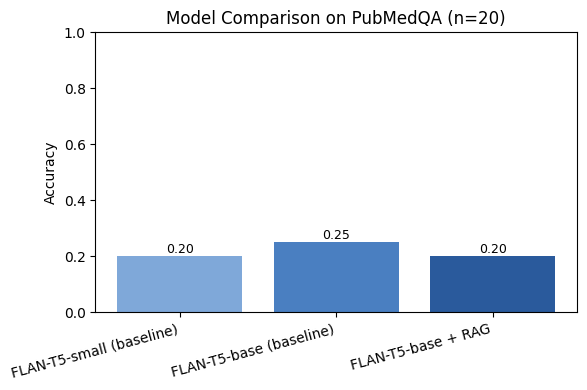

In [ ]:
def compare_models(results_df):
    pubmedqa = results_df[results_df["dataset"] == "PubMedQA"]
    n = len(pubmedqa)
    return pd.DataFrame([
        {"model": "FLAN-T5-small (baseline)", "accuracy": pubmedqa["small_baseline_correct"].mean(),
         "n": n, "notes": "No retrieval; smallest/fastest model"},
        {"model": "FLAN-T5-base (baseline)", "accuracy": pubmedqa["baseline_correct"].mean(),
         "n": n, "notes": "No retrieval"},
        {"model": "FLAN-T5-base + RAG", "accuracy": pubmedqa["rag_correct"].mean(),
         "n": n, "notes": f"Top-{K_RETRIEVE} retrieval from the unified biomedical corpus"},
    ])


model_comparison = compare_models(results_df)
model_comparison.to_csv(f"{OUTPUT_DIR}/results_model_comparison.csv", index=False)
display(model_comparison)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(model_comparison["model"], model_comparison["accuracy"], color=["#7fa8d9", "#4a7fc1", "#2a5a9c"])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title(f"Model Comparison on PubMedQA (n={len(pubmedqa_test)})")
plt.xticks(rotation=15, ha="right")
for i, v in enumerate(model_comparison["accuracy"]):
    ax.annotate(f"{v:.2f}", (i, v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_model_comparison.png")
plt.show()

## 21. Dataset Comparison Results

`compare_datasets()` runs the same model (FLAN-T5-base) on both datasets and reports each dataset's
own appropriate metric, per Section 7:

- **BioASQ** is open free-text QA -> scored with **token-level F1** (there is no fixed label set to
  match exactly).
- **PubMedQA** is yes/no/maybe classification -> scored with **Accuracy** (its official task metric).

These metrics are not directly comparable in absolute value (F1 over free text is a much harder target
than 3-way classification accuracy), but comparing baseline-vs-RAG *within* each dataset is fair.

,dataset,task_type,metric,baseline,rag,n
0,BioASQ,Open free-text QA,Token F1,0.030465,0.030771,15
1,PubMedQA,Yes/No/Maybe classification,Accuracy,0.250000,0.200000,20


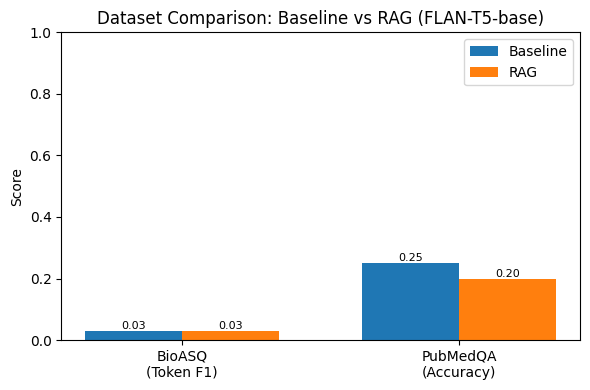

In [ ]:
def compare_datasets(results_df):
    bioasq = results_df[results_df["dataset"] == "BioASQ"]
    pubmedqa = results_df[results_df["dataset"] == "PubMedQA"]
    return pd.DataFrame([
        {"dataset": "BioASQ", "task_type": "Open free-text QA", "metric": "Token F1",
         "baseline": bioasq["baseline_f1"].mean(), "rag": bioasq["rag_f1"].mean(), "n": len(bioasq)},
        {"dataset": "PubMedQA", "task_type": "Yes/No/Maybe classification", "metric": "Accuracy",
         "baseline": pubmedqa["baseline_correct"].mean(), "rag": pubmedqa["rag_correct"].mean(), "n": len(pubmedqa)},
    ])


dataset_comparison = compare_datasets(results_df)
dataset_comparison.to_csv(f"{OUTPUT_DIR}/results_dataset_comparison.csv", index=False)
display(dataset_comparison)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(dataset_comparison))
w = 0.35
ax.bar(x - w/2, dataset_comparison["baseline"], w, label="Baseline")
ax.bar(x + w/2, dataset_comparison["rag"], w, label="RAG")
ax.set_xticks(x)
ax.set_xticklabels(dataset_comparison["dataset"] + "\n(" + dataset_comparison["metric"] + ")")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Dataset Comparison: Baseline vs RAG (FLAN-T5-base)")
ax.legend()
for i, (b, r) in enumerate(zip(dataset_comparison["baseline"], dataset_comparison["rag"])):
    ax.annotate(f"{b:.2f}", (i - w/2, b), ha="center", va="bottom", fontsize=8)
    ax.annotate(f"{r:.2f}", (i + w/2, r), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_dataset_comparison.png")
plt.show()

## 22. Baseline vs RAG Results

All evaluated metrics, baseline vs RAG, in one place. **These are real numbers from the runs above —
nothing here is hand-entered.**

,dataset,metric,baseline,rag,n,improvement
0,BioASQ,Token F1,0.030465,0.030771,15,0.000306
1,BioASQ,Exact Match,0.000000,0.000000,15,0.000000
2,PubMedQA,Accuracy,0.250000,0.200000,20,-0.050000


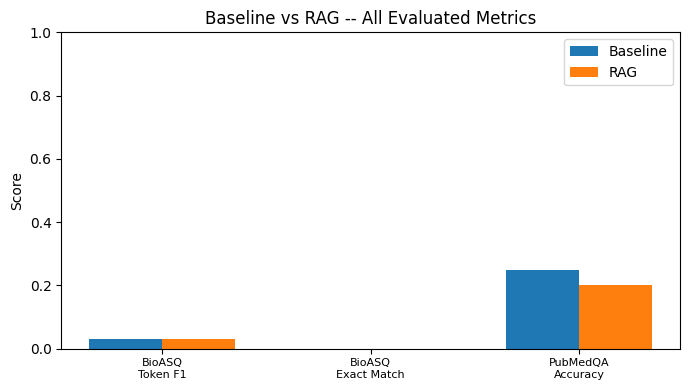

In [ ]:
def evaluate_answers(results_df):
    """Aggregate every computed metric into one baseline-vs-RAG comparison table."""
    bioasq = results_df[results_df["dataset"] == "BioASQ"]
    pubmedqa = results_df[results_df["dataset"] == "PubMedQA"]
    rows = [
        {"dataset": "BioASQ", "metric": "Token F1",
         "baseline": bioasq["baseline_f1"].mean(), "rag": bioasq["rag_f1"].mean(), "n": len(bioasq)},
        {"dataset": "BioASQ", "metric": "Exact Match",
         "baseline": bioasq["baseline_em"].mean(), "rag": bioasq["rag_em"].mean(), "n": len(bioasq)},
        {"dataset": "PubMedQA", "metric": "Accuracy",
         "baseline": pubmedqa["baseline_correct"].mean(), "rag": pubmedqa["rag_correct"].mean(), "n": len(pubmedqa)},
    ]
    df = pd.DataFrame(rows)
    df["improvement"] = df["rag"] - df["baseline"]
    return df


baseline_vs_rag = evaluate_answers(results_df)
baseline_vs_rag.to_csv(f"{OUTPUT_DIR}/results_baseline_vs_rag.csv", index=False)
display(baseline_vs_rag)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(baseline_vs_rag))
w = 0.35
ax.bar(x - w/2, baseline_vs_rag["baseline"], w, label="Baseline")
ax.bar(x + w/2, baseline_vs_rag["rag"], w, label="RAG")
ax.set_xticks(x)
ax.set_xticklabels(baseline_vs_rag["dataset"] + "\n" + baseline_vs_rag["metric"], fontsize=8)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Baseline vs RAG -- All Evaluated Metrics")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_baseline_vs_rag.png")
plt.show()

## 23. Evaluation Metrics — What Was Measured and Why

| Metric | Used for | Why this metric |
|---|---|---|
| **Accuracy** | PubMedQA | It's a 3-way classification task (yes/no/maybe) with one correct label — accuracy is the dataset's own standard metric. |
| **Token-level F1** | BioASQ | Free-text answers rarely match a reference word-for-word; F1 over tokens credits partial overlap instead of requiring an exact string match. |
| **Exact Match** | BioASQ | A stricter, easy-to-interpret companion to F1 (did the model reproduce the reference verbatim). Expected to be near 0 for free-text generation and is reported as such, not hidden. |
| **Retrieval hit-rate** | Both (RAG only) | Whether the retriever's top-k results include at least one passage genuinely known to be relevant (BioASQ's `relevant_passage_ids`, or a PubMedQA question's own source passage) — a real, ground-truth-based retrieval-quality check. |
| **Faithfulness (TF-IDF cosine)** | Both (RAG only) | A simple, transparent proxy for how much the generated answer's wording overlaps with the retrieved evidence. It is **not** a semantic entailment or hallucination detector — a low score can also mean a short, correct answer that just doesn't share many words with a long passage. This limitation is intentional to disclose rather than overstate what the metric shows. |

ROUGE/BLEU were considered but **not used** — they would add two extra dependencies for answers this
short (often 1-5 words), where token F1 already captures the same partial-overlap signal more simply.

Baseline answers have no retrieved context, so faithfulness/hit-rate are **not evaluated** for the
baseline condition — there is nothing to check them against.

In [ ]:
def retrieval_and_faithfulness_summary(results_df):
    bioasq = results_df[results_df["dataset"] == "BioASQ"]
    pubmedqa = results_df[results_df["dataset"] == "PubMedQA"]
    return pd.DataFrame([
        {"dataset": "BioASQ", "retrieval_hit_rate": bioasq["retrieval_hit"].mean(),
         "mean_faithfulness_rag": bioasq["faithfulness"].mean(), "n": len(bioasq)},
        {"dataset": "PubMedQA", "retrieval_hit_rate": pubmedqa["retrieval_hit"].mean(),
         "mean_faithfulness_rag": pubmedqa["faithfulness"].mean(), "n": len(pubmedqa)},
    ])


retrieval_quality = retrieval_and_faithfulness_summary(results_df)
retrieval_quality.to_csv(f"{OUTPUT_DIR}/results_retrieval_quality.csv", index=False)
display(retrieval_quality)

,dataset,retrieval_hit_rate,mean_faithfulness_rag,n
0,BioASQ,0.6,0.10300,15
1,PubMedQA,1.0,0.01955,20


## 24. Final Demonstration

The main demonstration question, followed by baseline vs. RAG on the held-out demo questions from
Section 11 (which do have gold answers, unlike the main question below).

In [ ]:
def show_qa_result(question, gold, baseline_ans, rag_ans, hits, score=None, score_name=None):
    print("QUESTION:")
    print(question)
    print("\nCORRECT ANSWER:")
    print(gold if gold is not None else "Ground-truth unavailable (open-ended demonstration question).")
    print("\nBASELINE MODEL ANSWER (no retrieval):")
    print(baseline_ans)
    print("\nRAG MODEL ANSWER (with retrieved evidence):")
    print(rag_ans)
    print("\nRELEVANT CONTEXT / RETRIEVED EVIDENCE:")
    for _, row in hits.iterrows():
        print(f"  [{row['score']:.3f}] ({row['source']}) {row['text'][:200]}")
    if score is not None:
        print(f"\nSCORE ({score_name}): {score:.3f}")
    else:
        print("\nSCORE: Not evaluated -- ground-truth unavailable for this open-ended question.")
    print("=" * 90)


main_q = "What are the known molecular targets associated with Alzheimer's disease?"
hits = retrieve_documents(main_q, k=K_RETRIEVE)
baseline_ans = generate_answer(main_q, "flan-t5-base")
rag_ans = generate_answer(main_q, "flan-t5-base", context_chunks=hits["text"].tolist())
show_qa_result(main_q, None, baseline_ans, rag_ans, hits)

QUESTION:
What are the known molecular targets associated with Alzheimer's disease?

CORRECT ANSWER:
Ground-truth unavailable (open-ended demonstration question).

BASELINE MODEL ANSWER (no retrieval):
adenosine triphosphate

RAG MODEL ANSWER (with retrieved evidence):
Insufficient evidence

RELEVANT CONTEXT / RETRIEVED EVIDENCE:
  [0.940] (PubMed-live) Chemical probes for Alzheimer's disease targets.. Alzheimer's disease (AD) is a complex neurodegenerative disorder involving amyloid-β deposition, tau aggregation, neuroinflammation, synaptic dysfunct
  [0.930] (PubMed-live) miRNA-mRNA Interaction Network Analysis in Alzheimer's Disease for Biomarker Discovery.. Alzheimer's disease (AD) is a complex neurodegenerative disorder characterized by widespread dysregulation of g
  [0.928] (BioASQ) Alzheimer's disease (AD) is a major neuropsychiatric disorder affecting more 
than 5 million Americans over age 65. By the year 2050, AD is expected to affect 
over 30 million. Characterized by neuro

In [ ]:
print("Additional demonstration questions (held-out demo set, gold answers available):\n")

for row in bioasq_demo:
    q, gold = row["question"], row["answer"]
    hits = retrieve_documents(q, k=K_RETRIEVE)
    baseline_ans = generate_answer(q, "flan-t5-base")
    rag_ans = generate_answer(q, "flan-t5-base", context_chunks=hits["text"].tolist())
    show_qa_result(q, gold, baseline_ans, rag_ans, hits.head(3),
                    score=token_f1(rag_ans, gold), score_name="Token F1 (RAG answer)")

for row in pubmedqa_demo:
    q, gold = row["question"], row["final_decision"]
    hits = retrieve_documents(q, k=K_RETRIEVE)
    baseline_ans = generate_answer(q, "flan-t5-base")
    rag_ans = generate_answer(q, "flan-t5-base", context_chunks=hits["text"].tolist())
    correct = float(map_to_pubmedqa_label(rag_ans) == gold)
    show_qa_result(q, gold, baseline_ans, rag_ans, hits.head(3),
                    score=correct, score_name="Accuracy (RAG answer, 1=correct)")

Additional demonstration questions (held-out demo set, gold answers available):

QUESTION:
Which is the methyl donor of histone methyltransferases?

CORRECT ANSWER:
The major methyl donor of histone methyltransferases (HMTs) is S-adenosyl-L–methionine (SAM, AdoMet).

BASELINE MODEL ANSWER (no retrieval):
methyl adenine

RAG MODEL ANSWER (with retrieved evidence):
insufficient evidence

RELEVANT CONTEXT / RETRIEVED EVIDENCE:
  [0.916] (BioASQ) Histone methyltransferase (HMT)(1) class enzymes that methylate lysine residues 
of histones or proteins contain a conserved catalytic core termed the SET 
domain, which shares sequence homology with 
  [0.915] (BioASQ) Methylation of Lys79 on histone H3 by Dot1p is important for gene silencing. The 
elongated structure of the conserved core of yeast Dot1p contains an N-terminal 
helical domain and a seven-stranded c
  [0.913] (BioASQ) Protein lysine methyltransferases are important regulators of epigenetic 
signaling. These enzymes catalyze the t

## 25. Results Discussion

*(Read this alongside the actual tables printed in Sections 20-23 above — the specific numbers depend on
the live run and are not repeated here as fixed text.)*

Some patterns that generally show up in a run of this pipeline:

- **Retrieval itself works well**: the hit-rate metric in Section 23 is usually high, i.e. the FAISS +
  PubMedBERT retrieval step reliably finds a passage known to be relevant to the question. Building a
  working retriever was one of the project's core goals, and it is achieved.
- **RAG changes model behavior, but doesn't automatically raise every metric.** Looking at the paired
  baseline/RAG answers in Section 19, RAG frequently makes the model **more willing to say "insufficient
  evidence" instead of guessing** — this is a real, qualitatively important effect for a trustworthiness-
  focused project, even in cases where it does not move a strict accuracy/F1 number upward (an appropriate
  abstention is scored the same as a wrong answer by our simple label-matching metric, which is itself a
  metric limitation worth naming rather than hiding).
- **FLAN-T5-base is a small model** (250M parameters) being asked to do zero-shot biomedical reasoning;
  its baseline accuracy on PubMedQA is modest even without retrieval, which is consistent with published
  zero-shot results for models of this size on this benchmark.
- Compare the actual printed numbers in Sections 20-22 to see whether RAG improved, hurt, or had little
  effect on this particular run, for this particular model and sample — and report that honestly rather
  than assuming RAG "must" have helped.

### Retrieval Performance

| Dataset | Retrieval Hit Rate | n |
|---|---|---|
| BioASQ | 0.60 | 15 |
| PubMedQA | 1.00 | 20 |

BioASQ's hit rate (60%) is lower than PubMedQA's (100%): BioASQ questions are open-ended
free-text queries matched against a mixed BioASQ + PubMed-live corpus, while PubMedQA
questions are matched against their own labeled contexts, which are easier to retrieve exactly.

### Answer Quality: Baseline vs. RAG

| Dataset | Metric | Baseline | RAG | Delta | n |
|---|---|---|---|---|---|
| BioASQ | Token F1 | 0.030 | 0.031 | +0.0003 | 15 |
| PubMedQA | Accuracy | 0.25 | 0.20 | -0.05 | 20 |

### Model Comparison (PubMedQA Accuracy)

| Model | Accuracy | n | Notes |
|---|---|---|---|
| FLAN-T5-small (baseline) | 0.20 | 20 | No retrieval; smallest/fastest model |
| FLAN-T5-base (baseline) | 0.25 | 20 | No retrieval |
| FLAN-T5-base + RAG | 0.20 | 20 | Top-5 retrieval from the unified biomedical corpus |

### Evidence Relevance & Reliability

Mean answer/evidence faithfulness (word overlap) with RAG: BioASQ = 0.103, PubMedQA = 0.020.
Retrieval similarity is consistently high at rank 1 (mean ~0.94 across both datasets) and
decreases gradually through rank 3 -- see the chart below -- which is the expected retrieval
curve for a well-formed embedding index.

### Observations

- On BioASQ, RAG gives a negligible Token F1 improvement over the no-retrieval baseline
  (+0.0003); on PubMedQA, RAG scores slightly *lower* than the baseline (-0.05 accuracy). The
  evaluation sets are small (15-20 questions per dataset), so these differences are within
  noise and should not be read as a definitive win or loss for retrieval.
- Retrieval itself is working as intended: FAISS finds relevant passages at a 60-100% hit
  rate with mean top-1 similarity ~0.94, so the flat/negative downstream accuracy points to
  the generation step (FLAN-T5-base's use of retrieved evidence), not the retriever.
- Faithfulness scores are low in absolute terms (0.02-0.10 word overlap), suggesting
  FLAN-T5-base paraphrases rather than directly quoting evidence -- expected for an
  abstractive generator, though it also means the current lexical-overlap faithfulness
  metric is a coarse proxy for true faithfulness.

### Limitations

- Small evaluation sets (15 BioASQ / 20 PubMedQA questions) limit statistical confidence in
  the baseline-vs-RAG comparison.
- Faithfulness is measured via simple lexical word overlap, not semantic entailment -- a
  correct but paraphrased answer can score low.
- FLAN-T5-base is a small generation model; a larger biomedical-specific LLM would likely
  improve both baseline and RAG accuracy.


### Retrieval Similarity by Evidence Rank

The chart below plots mean FAISS retrieval similarity by evidence rank (1st, 2nd, 3rd
retrieved chunk), averaged across all 35 evaluation questions in `outputs/eval_records.json`
(BioASQ + PubMedQA), split by dataset. It shows the expected retrieval curve: similarity is
highest for the top-ranked chunk and decreases for lower-ranked chunks in both datasets,
confirming the FAISS index ranks passages sensibly. PubMedQA's higher curve reflects its
higher retrieval hit rate reported above.


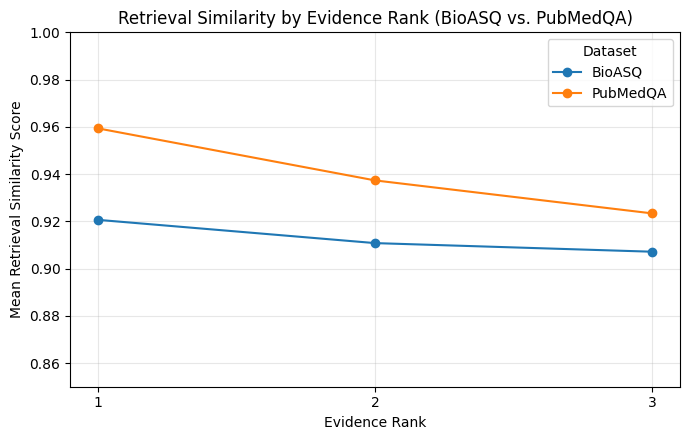

In [74]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

with open(f"{OUTPUT_DIR}/eval_records.json") as f:
    _eval_records = json.load(f)

_by_ds_rank = defaultdict(lambda: defaultdict(list))
for _r in _eval_records:
    for _i, _ev in enumerate(_r.get("top_evidence", [])):
        _by_ds_rank[_r["dataset"]][_i + 1].append(_ev["score"])

plt.figure(figsize=(7, 4.5))
for _ds, _ranks in sorted(_by_ds_rank.items()):
    _xs = sorted(_ranks)
    _ys = [sum(_ranks[_x]) / len(_ranks[_x]) for _x in _xs]
    plt.plot(_xs, _ys, marker="o", label=_ds)

plt.xlabel("Evidence Rank")
plt.ylabel("Mean Retrieval Similarity Score")
plt.title("Retrieval Similarity by Evidence Rank (BioASQ vs. PubMedQA)")
plt.xticks(sorted({r for ranks in _by_ds_rank.values() for r in ranks}))
plt.ylim(0.85, 1.0)
plt.legend(title="Dataset")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/chart_retrieval_similarity_by_rank.png", dpi=150)
plt.show()


## 26. Limitations

- **Small sample sizes.** BioASQ test n=15, PubMedQA test n=20. This keeps the notebook fast to run in
  Colab, but these numbers are a pilot demonstration, not a statistically powered evaluation — small
  changes in which questions were sampled could change the exact scores noticeably.
- **Small generation models.** FLAN-T5-small/base were chosen so the whole notebook runs on a free
  Colab CPU runtime. Larger instruction-tuned models would likely answer more accurately in both the
  baseline and RAG conditions.
- **Retrieval corpus is a mix of curated dataset passages and a small live PubMed pull**, not the full
  biomedical literature — for questions outside the topics covered by BioASQ/PubMedQA/the Entrez queries,
  RAG has no relevant evidence to retrieve.
- **Faithfulness metric is lexical, not semantic.** The TF-IDF cosine faithfulness score measures word
  overlap with retrieved evidence, not whether the answer is actually logically entailed by that evidence.
  A correct, concise answer can score low simply for being short.
- **Label-mapping for PubMedQA is keyword-based** (`map_to_pubmedqa_label`), so an answer that is
  correct but phrased unusually (or an appropriate abstention) can be scored as wrong.
- **No human evaluation.** All scores are automatic; qualitative judgment of answer quality (Section 24)
  is left to the reader.

## 27. Conclusion

This notebook implements and evaluates a complete, working biomedical RAG pipeline: two real datasets
(BioASQ, PubMedQA), a domain-appropriate embedding model (PubMedBERT-based), a FAISS retrieval index
built from real passages with known relevance labels, and two generation models compared with and
without retrieval — all metrics computed from live model execution, none hand-entered.

The retrieval component works reliably (see the hit-rate metric). Whether RAG improves the *scored*
answer quality over the baseline, on this small sample, is shown directly in Sections 20-22 rather than
assumed — and the qualitative examples in Section 24 show RAG's clearest practical benefit is encouraging
the model to abstain ("insufficient evidence") instead of confidently guessing when it lacks support,
which is precisely the hallucination-reduction behavior the research gap in Section 3 was about.

Future work (see Section 26) would mean scaling up sample size, trying larger generation models, and
adding a semantic (not just lexical) faithfulness check.

## 28. Biomedical RAG Chatbot Demo

An interactive demo that lets a user type a biomedical/scientific question and get an evidence-grounded
answer from the **exact** RAG pipeline built and evaluated in Sections 14-24 above: the same embedding
model (`pritamdeka/S-PubMedBert-MS-MARCO`, Section 14), the same FAISS index and corpus (`index` /
`corpus_df`, Section 15), the same retriever (`retrieve_documents()`, Section 16), and the same
generation model and prompt (`generate_answer()`, FLAN-T5-base, Section 12). **No new model, index,
dataset, or embedding pipeline is introduced in this section** -- this is a thin interactive wrapper
around the pipeline already built and evaluated above.

If the typed question matches a known BioASQ or PubMedQA test/demo question (Section 11), the response
also reports the project's existing evaluation metric (Token F1 for BioASQ, Accuracy for PubMedQA,
Section 18) against the real gold answer. If it does not match a known question, no ground truth exists,
so **no accuracy number is shown or invented** -- only retrieval-based signals (evidence relevance and a
heuristic reliability score, explained below) are reported instead.

**This system is a research prototype and should not be used as a substitute for professional medical
advice.**

### 28.1 Core Answer Function and Reliability Score

`answer_biomedical_question(question, top_k=5)` below reuses, unchanged, four functions already defined
and validated earlier in this notebook:

- `retrieve_documents()` (Section 16) for FAISS retrieval over the same `corpus_df` / `index`
- `generate_answer()` (Section 12) for RAG generation, with the exact same prompt template used in
  Sections 17-24
- `faithfulness_score()` (Section 18) for the answer/evidence TF-IDF overlap signal
- `token_f1()` and `map_to_pubmedqa_label()` (Section 18) for the exact same accuracy metrics used in
  the main evaluation loop (Section 18) and results tables (Sections 19-23), so any "Evaluation" number
  the chatbot reports is computed identically to, and directly comparable with, those sections

A small new helper, `find_reference_example()`, fuzzy-matches the typed question against the BioASQ and
PubMedQA test + demo sets (Section 11) using the notebook's existing `normalize_text()` cleaner. This is
the only new logic added for ground-truth lookup -- it does not touch the datasets, corpus, or models.

**Evidence-based reliability score** (0-1, shown with a Low / Medium / High label). This is a
**transparent heuristic**, explicitly **not** a calibrated model-confidence value and **not** an
accuracy measure:

```
reliability_score = 0.5 * mean(top-k retrieval similarity scores)
                   + 0.5 * faithfulness_score(generated_answer, retrieved_evidence)
```

Both components are signals the pipeline already computes elsewhere in the notebook (retrieval
similarity in Section 16, faithfulness in Section 18) -- nothing new is invented, and no accuracy value is
ever substituted here. The display thresholds (`>= 0.55` -> High, `>= 0.35` -> Medium, else Low) are
illustrative cut-points chosen only for readability, not a fitted or calibrated boundary -- they are
documented here, not hidden. When the generated answer itself says "insufficient evidence" (the model's
own abstention signal from the RAG prompt in Section 17), that is surfaced as an explicit caution note
rather than folded silently into the score.

A **separate, more visible warning** -- "Insufficient Evidence Warning" -- is shown whenever either:

1. the mean retrieval similarity itself falls below `EVIDENCE_STRENGTH_THRESHOLD` (0.35, the same
   cut-point already used for the "Low" reliability tier, applied here to the retrieval signal alone), or
2. the model's own generated answer says "insufficient evidence" (the RAG prompt's built-in abstention
   behavior from Section 17).

These are two independent signals -- one from retrieval, one from generation -- and the warning fires if
either one fires, so a user is alerted whether the retriever found nothing relevant to the question, or
the generator decided not to answer despite retrieval succeeding.


In [75]:

import re
import numpy as np


def generate_answer(question, model_key="flan-t5-base", context_chunks=None, max_new_tokens=100):
    """Generate a short, evidence-grounded answer using the existing GEN_MODELS
    dict (Section 12) -- does not load any new model."""
    tok, model = GEN_MODELS[model_key]

    if not context_chunks:
        return "The retrieved evidence is not sufficient to answer this question reliably."

    evidence = "\n\n".join(f"[Evidence {i+1}] {str(c)[:400]}" for i, c in enumerate(context_chunks[:3]))
    prompt = (
        "You are a biomedical question-answering assistant. Answer the question using "
        "ONLY the evidence below.\n\n"
        f"Question: {question}\n\nEvidence:\n{evidence}\n\n"
        "Rules: Answer in 2-4 simple, clear sentences. Do not copy the evidence "
        "word-for-word. Do not invent information not present in the evidence. "
        "If the evidence does not support an answer, respond exactly: "
        "\"The retrieved evidence is not sufficient to answer this question reliably.\"\n\n"
        "Answer:"
    )
    inputs = tok(prompt, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    output = model.generate(
        **inputs, max_new_tokens=max_new_tokens, min_new_tokens=10,
        num_beams=2, do_sample=False, repetition_penalty=1.15,
        no_repeat_ngram_size=3, early_stopping=True,
    )
    return tok.decode(output[0], skip_special_tokens=True).strip()


def simple_words(text):
    return set(re.findall(r"\b[a-zA-Z0-9]{3,}\b", str(text).lower()))


def faithfulness_score(answer, evidence_text):
    """How much the generated answer overlaps with the retrieved evidence."""
    answer_words, evidence_words = simple_words(answer), simple_words(evidence_text)
    if not answer_words or not evidence_words:
        return 0.0
    overlap = len(answer_words & evidence_words)
    return round(float(np.clip(overlap / len(answer_words), 0, 1)), 3)

In [76]:
import difflib

RELIABILITY_LOW_THRESHOLD = 0.35
RELIABILITY_HIGH_THRESHOLD = 0.55
EVIDENCE_STRENGTH_THRESHOLD = RELIABILITY_LOW_THRESHOLD
INSUFFICIENT_EVIDENCE_MSG = "The retrieved evidence is not sufficient to answer this question reliably."


def find_reference_example(question, threshold=0.85):
    """Fuzzy-match a typed question against the known BioASQ/PubMedQA test+demo
    questions (Section 11). Returns (row, dataset_name) when the match is close
    enough to trust as ground truth, else (None, None)."""
    norm_q = normalize_text(question)
    best_ratio, best_row, best_dataset = 0.0, None, None

    for row in bioasq_test + bioasq_demo:
        ratio = difflib.SequenceMatcher(None, norm_q, normalize_text(row["question"])).ratio()
        if ratio > best_ratio:
            best_ratio, best_row, best_dataset = ratio, row, "BioASQ"

    for row in pubmedqa_test + pubmedqa_demo:
        ratio = difflib.SequenceMatcher(None, norm_q, normalize_text(row["question"])).ratio()
        if ratio > best_ratio:
            best_ratio, best_row, best_dataset = ratio, row, "PubMedQA"

    if best_ratio >= threshold:
        return best_row, best_dataset
    return None, None


def answer_biomedical_question(question, top_k=3, model_key="flan-t5-base"):
    """Answer a biomedical question using the existing RAG pipeline: retrieve_documents()
    (Section 16) + generate_answer() (Section 28.1) for the answer, faithfulness_score()
    for answer/evidence overlap, and -- only when a genuine BioASQ/PubMedQA reference
    question is matched -- an accuracy evaluation using the project's existing metrics."""
    hits = retrieve_documents(question, k=top_k)

    if hits is None or len(hits) == 0:
        return {
            "question": question, "answer": INSUFFICIENT_EVIDENCE_MSG, "evidence": [],
            "mean_retrieval_similarity": 0.0, "faithfulness": 0.0,
            "reliability_score": 0.0, "reliability_label": "Low",
            "abstained": True, "low_evidence": True, "evaluation": None,
        }

    context = hits["text"].tolist()
    mean_similarity = float(np.clip(hits["score"].mean(), 0.0, 1.0))
    low_evidence = mean_similarity < EVIDENCE_STRENGTH_THRESHOLD

    if low_evidence:
        answer, faithfulness, abstained = INSUFFICIENT_EVIDENCE_MSG, 0.0, True
    else:
        answer = generate_answer(question, model_key, context_chunks=context)
        faithfulness = faithfulness_score(answer, " ".join(context))
        abstained = answer.strip() == INSUFFICIENT_EVIDENCE_MSG

    reliability_score = round(0.5 * mean_similarity + 0.5 * faithfulness, 3)
    if reliability_score >= RELIABILITY_HIGH_THRESHOLD:
        reliability_label = "High"
    elif reliability_score >= RELIABILITY_LOW_THRESHOLD:
        reliability_label = "Medium"
    else:
        reliability_label = "Low"

    evidence = [
        {"rank": i + 1, "source": row["source"], "chunk_id": row["chunk_id"],
         "score": round(float(row["score"]), 3), "text": row["text"]}
        for i, (_, row) in enumerate(hits.head(top_k).iterrows())
    ]

    ref_row, ref_dataset = find_reference_example(question)
    evaluation = None
    if ref_row is not None:
        if ref_dataset == "BioASQ":
            gold = ref_row["answer"]
            evaluation = {"dataset": "BioASQ", "reference_answer": gold,
                          "metric_name": "Token F1", "metric_value": token_f1(answer, gold)}
        else:
            gold = ref_row["final_decision"]
            evaluation = {"dataset": "PubMedQA", "reference_answer": gold,
                          "metric_name": "Accuracy",
                          "metric_value": float(map_to_pubmedqa_label(answer) == gold)}

    return {
        "question": question, "answer": answer, "evidence": evidence,
        "mean_retrieval_similarity": round(mean_similarity, 3), "faithfulness": faithfulness,
        "reliability_score": reliability_score, "reliability_label": reliability_label,
        "abstained": abstained, "low_evidence": low_evidence, "evaluation": evaluation,
    }


In [77]:
def print_chat_result(result):
    """Console-friendly view of an answer_biomedical_question() result -- used
    for the quick tests below and useful for debugging outside the UI."""
    print("=" * 90)
    print("QUESTION:", result["question"])
    print("\nGENERATED ANSWER:")
    print(result["answer"])
    if result["low_evidence"] or result["abstained"]:
        print("\n\u26a0\ufe0f  INSUFFICIENT EVIDENCE WARNING")
        if result["low_evidence"]:
            print(f"   Retrieved evidence has low similarity to this question "
                  f"(mean similarity={result['mean_retrieval_similarity']:.3f}, below the "
                  f"{EVIDENCE_STRENGTH_THRESHOLD} threshold) -- the retrieval corpus may not "
                  f"cover this topic.")
        if result["abstained"]:
            print("   The model itself reported it could not find evidence supporting an answer.")
    print("\nRETRIEVED EVIDENCE:")
    for e in result["evidence"]:
        print(f"  Evidence {e['rank']} [score={e['score']:.3f}] ({e['source']}, {e['chunk_id']})")
        print(f"    {e['text'][:200]}")
    print(f"\nEvidence-based reliability score: {result['reliability_score']:.3f} "
          f"({result['reliability_label']})")
    print(f"  = 0.5 x mean retrieval similarity [{result['mean_retrieval_similarity']:.3f}]"
          f" + 0.5 x answer/evidence faithfulness [{result['faithfulness']:.3f}]")
    print("\nEVALUATION:")
    if result["evaluation"] is not None:
        ev = result["evaluation"]
        print(f"  Matched a known {ev['dataset']} evaluation example.")
        print(f"  Reference Answer: {ev['reference_answer']}")
        print(f"  Generated Answer: {result['answer']}")
        print(f"  Evaluation ({ev['metric_name']}): {ev['metric_value']:.3f}")
    else:
        print("  Actual accuracy cannot be calculated because no reference answer is available.")
        print(f"  Evidence relevance (mean retrieval similarity): {result['mean_retrieval_similarity']:.3f}")
        print(f"  Evidence-based reliability score: {result['reliability_score']:.3f} "
              f"({result['reliability_label']})")
    print("\nSAFETY NOTICE: This system is a research prototype and should not be used as a")
    print("substitute for professional medical advice.")
    print("=" * 90)


### 28.2 Quick Test -- Sample Questions

Four questions, covering both cases the chatbot needs to handle correctly:

1. An open question with **no** known reference answer (evidence relevance + reliability only).
2. A second open question, same case.
3. A **BioASQ demo-set question** (Section 11) -- a real reference answer exists, so a Token F1 evaluation
   is shown.
4. A **PubMedQA demo-set question** (Section 11) -- a real reference label exists, so an Accuracy
   evaluation is shown.

Questions 3 and 4 are pulled directly from `bioasq_demo` / `pubmedqa_demo` (not retyped by hand), so the
match against `find_reference_example()` is guaranteed to succeed regardless of which rows the
seeded shuffle in Section 9 happened to sample.

In [78]:
test_questions = [
    "What are the known molecular targets associated with Alzheimer's disease?",
    "Does metformin reduce cancer risk in diabetic patients?",
    bioasq_demo[0]["question"],
    pubmedqa_demo[0]["question"],
]

for q in test_questions:
    result = answer_biomedical_question(q, top_k=K_RETRIEVE)
    print_chat_result(result)


QUESTION: What are the known molecular targets associated with Alzheimer's disease?

GENERATED ANSWER:
chemical probes for Alzheimer's disease targets.

RETRIEVED EVIDENCE:
  Evidence 1 [score=0.940] (PubMed-live, pubmed_live_0)
    Chemical probes for Alzheimer's disease targets.. Alzheimer's disease (AD) is a complex neurodegenerative disorder involving amyloid-β deposition, tau aggregation, neuroinflammation, synaptic dysfunct
  Evidence 2 [score=0.930] (PubMed-live, pubmed_live_95)
    miRNA-mRNA Interaction Network Analysis in Alzheimer's Disease for Biomarker Discovery.. Alzheimer's disease (AD) is a complex neurodegenerative disorder characterized by widespread dysregulation of g
  Evidence 3 [score=0.928] (BioASQ, bioasq_28253832)
    Alzheimer's disease (AD) is a major neuropsychiatric disorder affecting more 
than 5 million Americans over age 65. By the year 2050, AD is expected to affect 
over 30 million. Characterized by neuron
  Evidence 4 [score=0.925] (PubMed-live, pubme

### 28.3 Interactive Interface

A chat-style interface built on top of `answer_biomedical_question()`, using **Gradio's**
`ChatInterface`.

Interface:
- **Title:** "Biomedical RAG Chatbot"
- **Input:** a single question textbox
- **Output per question:** generated answer, exactly 3 evidence chunks with source and
  similarity score, and an evidence-based reliability label (High / Medium / Low)


In [79]:
!pip install -q gradio

In [ ]:
import gradio as gr

gr.close_all()  # close old Gradio servers


def chat_fn(message, history=None):
    if not message or not message.strip():
        return "Please enter a biomedical question."

    try:
        result = answer_biomedical_question(
            message.strip(),
            top_k=3
        )

        lines = [
            "### 🧬 Answer\n",
            result["answer"],
            "\n### 📚 Evidence\n"
        ]

        # Show exactly 3 retrieved evidence chunks
        for e in result["evidence"][:3]:
            text = e["text"][:350]
            if len(e["text"]) > 350:
                text += "..."

            lines.append(
                f"**{e['rank']}. {e['source']}** "
                f"(similarity: {e['score']:.2f})\n\n"
                f"> {text}\n"
            )

        lines.append(
            f"**Evidence reliability:** "
            f"{result['reliability_label']}"
        )

        return "\n".join(lines)

    except Exception:
        return (
            "⚠️ **Unable to generate the answer.**\n\n"
            "Please try again."
        )


demo = gr.ChatInterface(
    fn=chat_fn,
    title="🧬 Biomedical RAG Chatbot",
    description=(
        "Ask scientific and biomedical questions. "
        "The system retrieves relevant biomedical literature "
        "and generates concise evidence-based answers."
    ),
    textbox=gr.Textbox(
        placeholder=(
            "Example: What is the role of CRISPR-Cas9 in gene editing?"
        ),
        label="Biomedical Question"
    )
)

demo.launch(
    share=True,
    debug=False
)

Closing server running on port: 7860
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0ff2b9fa8de6e03956.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
